Mean:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64
Median:
 sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64
Variance:
 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64
Standard Deviation:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


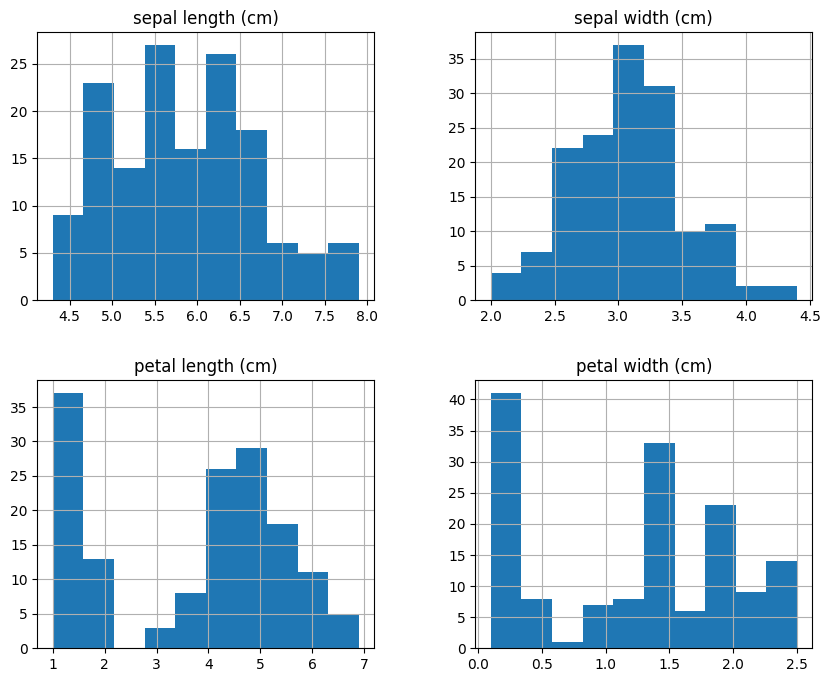

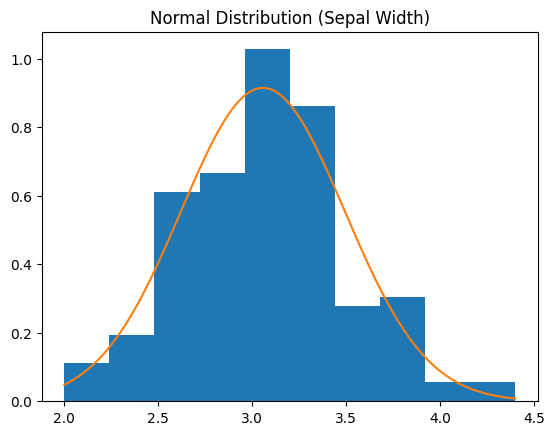

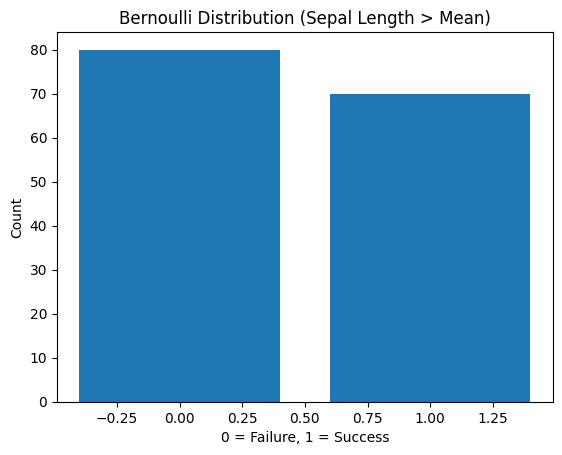

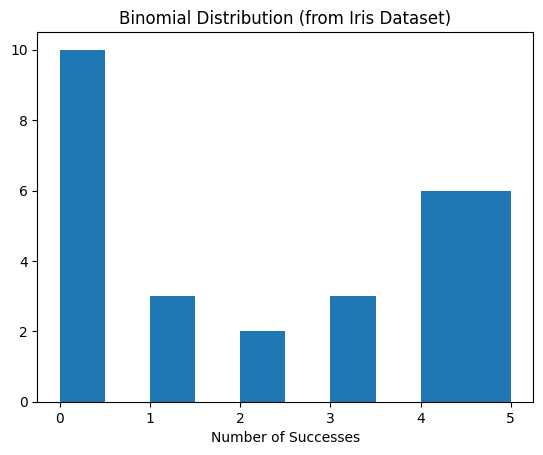

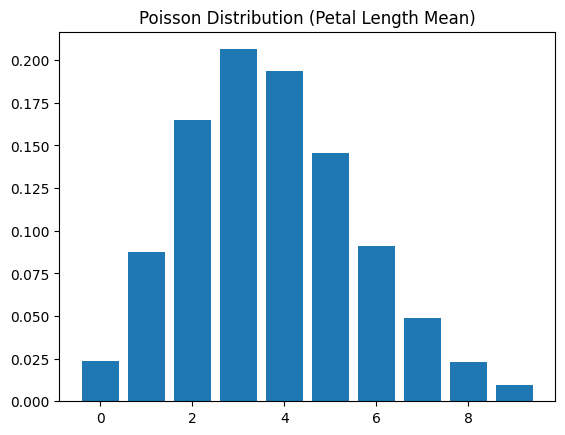

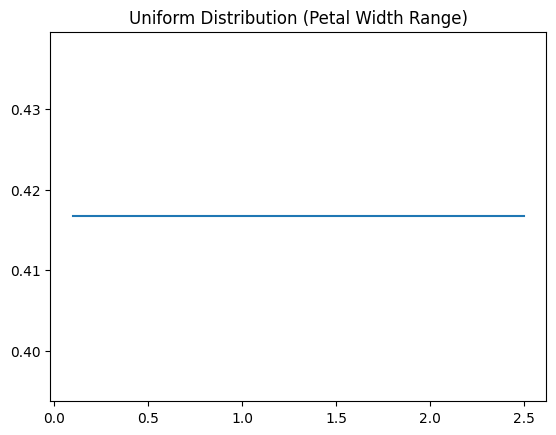

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.stats import norm, poisson, uniform

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Statistical Analysis
print("Mean:\n", df.mean())
print("Median:\n", df.median())
print("Variance:\n", df.var())
print("Standard Deviation:\n", df.std())

# Histograms of all features
df.hist(figsize=(10, 8))
plt.show()

# Normal Distribution (Sepal Width)
data = df['sepal width (cm)']
x = np.linspace(min(data), max(data), 100)
y = norm.pdf(x, data.mean(), data.std())
plt.hist(data, density=True)
plt.plot(x, y)
plt.title("Normal Distribution (Sepal Width)")
plt.show()

# Bernoulli Distribution
mean_value = df['sepal length (cm)'].mean()
bernoulli_data = (df['sepal length (cm)'] > mean_value).astype(int)
plt.bar([0, 1], bernoulli_data.value_counts().sort_index())
plt.title("Bernoulli Distribution (Sepal Length > Mean)")
plt.xlabel("0 = Failure, 1 = Success")
plt.ylabel("Count")
plt.show()

# Binomial Distribution
binomial_data = []
data = bernoulli_data.values
for i in range(0, len(data), 5):
    group = data[i:i+5]
    binomial_data.append(sum(group))
plt.hist(binomial_data)
plt.title("Binomial Distribution (from Iris Dataset)")
plt.xlabel("Number of Successes")
plt.show()

# Poisson Distribution
lambda_value = df['petal length (cm)'].mean()
poisson_data = poisson.pmf(np.arange(0, 10), lambda_value)
plt.bar(np.arange(0, 10), poisson_data)
plt.title("Poisson Distribution (Petal Length Mean)")
plt.show()

# Uniform Distribution
min_val = df['petal width (cm)'].min()
max_val = df['petal width (cm)'].max()
x = np.linspace(min_val, max_val, 100)
y = uniform.pdf(x, min_val, max_val - min_val)
plt.plot(x, y)
plt.title("Uniform Distribution (Petal Width Range)")
plt.show()